# Probability Density Function (PDF)

A **Probability Density Function (PDF)** describes the probability distribution of a **continuous random variable**. Unlike discrete variables, a continuous random variable can take any real value in a range — making it impossible to assign non-zero probability to a single point.

## Continuous Random Variable

A **continuous random variable** $x$ takes any real value from a continuous range:

$$x \in \mathbb{R}$$

Because there are **infinitely many possible values**, it is not meaningful to ask:

> *"What is the probability that $x$ takes exactly this value?"*

Instead, we ask:

> *"What is the probability that $x$ falls within some range $[a, b]$?"*

### Example — Human Being Data

| Random Variable | Description | Range |
|---|---|---|
| $x$ | Height of a person | 90 cm to 210 cm |
| $y$ | Weight of a person | 20 kg to 120 kg |

- **Sample space $S$**: the space of all human beings
- The random variable $x$ maps each person → their height (a real number)
- The random variable $y$ maps each person → their weight (a real number)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from scipy.stats import norm, uniform, expon, beta as beta_dist
from scipy.integrate import quad

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})

## Illustration — Sample Space → Continuous Random Variable

The diagram below shows how continuous random variables map the sample space (human beings) to real-valued measurements: height $x$ and weight $y$.

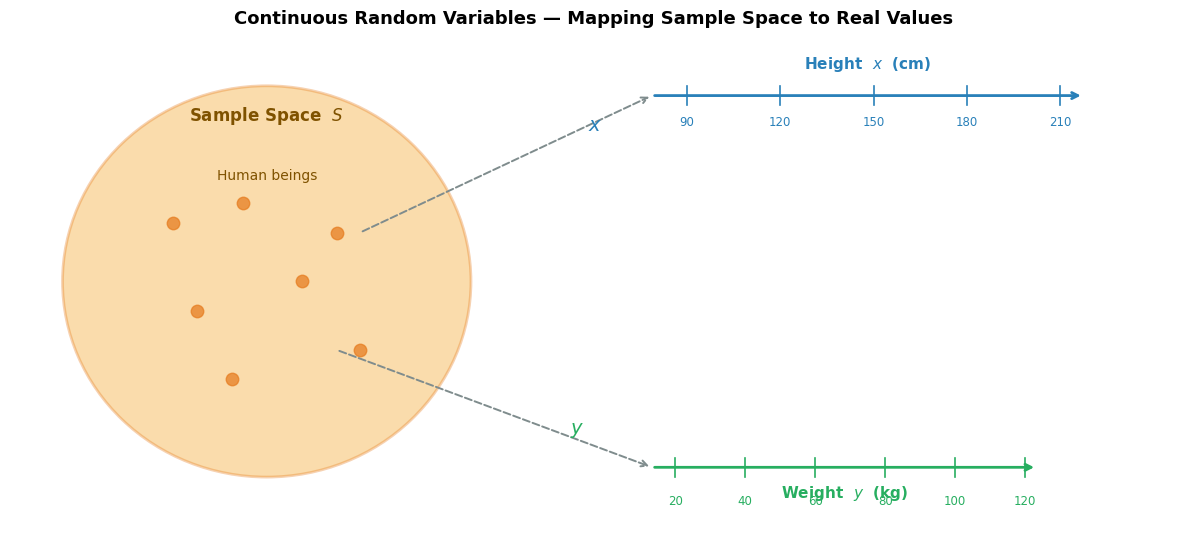

In [2]:
# --- Sample Space → Continuous RV illustration ---
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis('off')

# Sample space blob (left)
blob = Ellipse((2.2, 2.5), width=3.5, height=4.0,
               facecolor='#f39c12', alpha=0.35, edgecolor='#e67e22', linewidth=2)
ax.add_patch(blob)
ax.text(2.2, 4.15, 'Sample Space  $S$', ha='center', fontsize=12, fontweight='bold', color='#7f5200')
ax.text(2.2, 3.55, 'Human beings', ha='center', fontsize=10, color='#7f5200')

# People dots
people = [(1.4, 3.1), (2.0, 3.3), (2.8, 3.0), (1.6, 2.2), (2.5, 2.5), (3.0, 1.8), (1.9, 1.5)]
for px, py in people:
    ax.plot(px, py, 'o', markersize=9, color='#e67e22', alpha=0.75)

# Height axis (top right)
ax.annotate('', xy=(9.2, 4.4), xytext=(5.5, 4.4),
            arrowprops=dict(arrowstyle='->', color='#2980b9', lw=2))
ax.text(7.35, 4.68, 'Height  $x$  (cm)', ha='center', fontsize=11, color='#2980b9', fontweight='bold')
for tick, label in zip([5.8, 6.6, 7.4, 8.2, 9.0], ['90', '120', '150', '180', '210']):
    ax.plot([tick, tick], [4.3, 4.5], color='#2980b9', lw=1.2)
    ax.text(tick, 4.1, label, ha='center', fontsize=8.5, color='#2980b9')

# Weight axis (bottom right)
ax.annotate('', xy=(8.8, 0.6), xytext=(5.5, 0.6),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))
ax.text(7.15, 0.30, 'Weight  $y$  (kg)', ha='center', fontsize=11, color='#27ae60', fontweight='bold')
for tick, label in zip([5.7, 6.3, 6.9, 7.5, 8.1, 8.7], ['20', '40', '60', '80', '100', '120']):
    ax.plot([tick, tick], [0.5, 0.7], color='#27ae60', lw=1.2)
    ax.text(tick, 0.22, label, ha='center', fontsize=8.5, color='#27ae60')

# Arrows from blob to axes
ax.annotate('', xy=(5.5, 4.4), xytext=(3.0, 3.0),
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.4, linestyle='dashed'))
ax.annotate('', xy=(5.5, 0.6), xytext=(2.8, 1.8),
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.4, linestyle='dashed'))

ax.text(4.95, 4.05, '$x$', fontsize=14, color='#2980b9', style='italic', fontweight='bold')
ax.text(4.80, 0.95, '$y$', fontsize=14, color='#27ae60', style='italic', fontweight='bold')
ax.set_title('Continuous Random Variables — Mapping Sample Space to Real Values',
             fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## Definition — Probability Density Function

The **probability density function (PDF)** $p(x)$ of a continuous random variable $x$ satisfies:

$$\Pr[a \leq x \leq b] = \int_a^b p(x)\, dx$$

It tells us the **density** of probability — how tightly packed the probability is around each value of $x$.

### Properties of a Valid PDF

1. **Non-negativity**: $p(x) \geq 0$ for all $x$
2. **Normalization**: $\displaystyle\int_{-\infty}^{\infty} p(x)\, dx = 1$
3. **Point probability is zero**: $P(X = c) = 0$ for any single point $c$

> **NOTE:** $p(x)$ itself is **not** a probability — it is a *density*. It can exceed 1. Only the **area** under $p(x)$ over an interval is a probability.

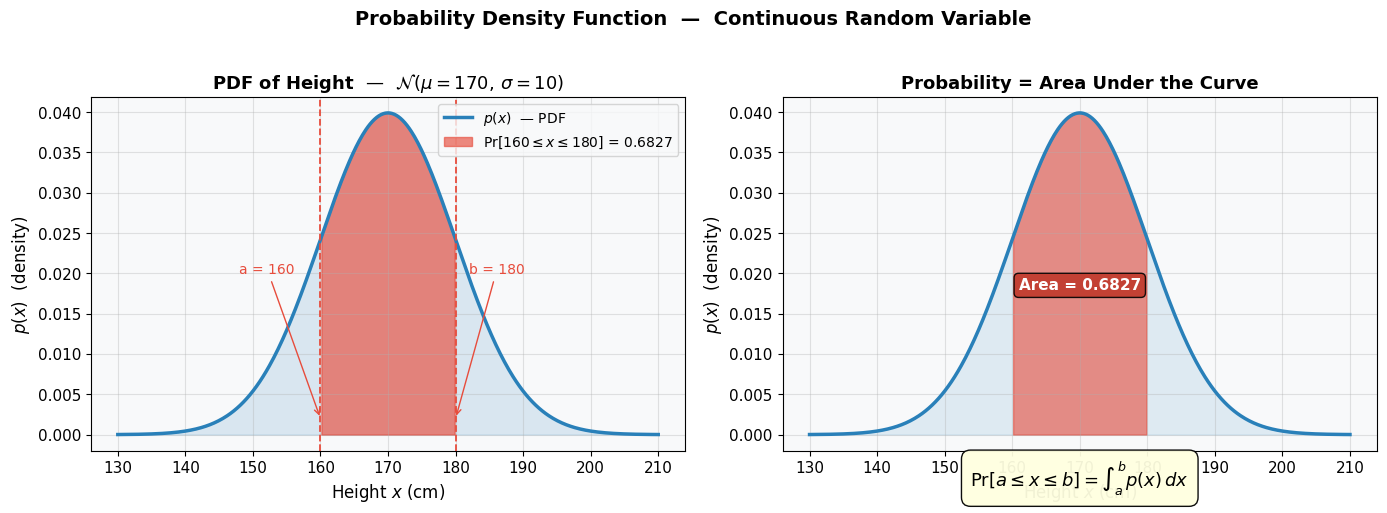

Pr[160 ≤ x ≤ 180]  =  ∫ p(x) dx  =  0.682689
Total area under PDF (±8σ) = 1.000000  (must ≈ 1)


In [4]:
# --- Core PDF concept: area under the curve = probability ---
mu, sigma = 170, 10   # height in cm
x = np.linspace(130, 210, 500)
pdf = norm.pdf(x, mu, sigma)

a, b = 160, 180
prob_ab, _ = quad(norm.pdf, a, b, args=(mu, sigma))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full PDF with shaded interval
ax1 = axes[0]
ax1.plot(x, pdf, color='#2980b9', linewidth=2.5, label='$p(x)$  — PDF')
ax1.fill_between(x, pdf, alpha=0.15, color='#2980b9')
mask = (x >= a) & (x <= b)
ax1.fill_between(x[mask], pdf[mask], alpha=0.65, color='#e74c3c',
                 label=f'$\\Pr[{a} \\leq x \\leq {b}]$ = {prob_ab:.4f}')
ax1.axvline(a, color='#e74c3c', linestyle='--', linewidth=1.3)
ax1.axvline(b, color='#e74c3c', linestyle='--', linewidth=1.3)
ax1.annotate(f'a = {a}', xy=(a, 0.002), xytext=(a - 12, 0.020),
             arrowprops=dict(arrowstyle='->', color='#e74c3c'), color='#e74c3c', fontsize=10)
ax1.annotate(f'b = {b}', xy=(b, 0.002), xytext=(b + 2, 0.020),
             arrowprops=dict(arrowstyle='->', color='#e74c3c'), color='#e74c3c', fontsize=10)
ax1.set_xlabel('Height $x$ (cm)', fontsize=12)
ax1.set_ylabel('$p(x)$  (density)', fontsize=12)
ax1.set_title('PDF of Height  —  $\\mathcal{N}(\\mu=170,\\, \\sigma=10)$', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)

# Right: annotated integral label
ax2 = axes[1]
ax2.plot(x, pdf, color='#2980b9', linewidth=2.5)
ax2.fill_between(x, pdf, alpha=0.12, color='#2980b9')
mask2 = (x >= a) & (x <= b)
ax2.fill_between(x[mask2], pdf[mask2], alpha=0.60, color='#e74c3c')
mid_y = norm.pdf((a + b) / 2, mu, sigma) * 0.45
ax2.text((a + b) / 2, mid_y, f'Area = {prob_ab:.4f}', ha='center', fontsize=11,
         fontweight='bold', color='white',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#c0392b', alpha=0.9))
ax2.text(0.5, -0.10, r'$\Pr[a \leq x \leq b] = \int_a^b p(x)\, dx$',
         ha='center', transform=ax2.transAxes, fontsize=13,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.95))
ax2.set_xlabel('Height $x$ (cm)', fontsize=12)
ax2.set_ylabel('$p(x)$  (density)', fontsize=12)
ax2.set_title('Probability = Area Under the Curve', fontsize=13, fontweight='bold')

plt.suptitle('Probability Density Function  —  Continuous Random Variable',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Use a wide finite range (±8σ) to avoid numerical issues with infinite bounds
total, _ = quad(norm.pdf, mu - 8*sigma, mu + 8*sigma, args=(mu, sigma))
print(f"Pr[{a} ≤ x ≤ {b}]  =  ∫ p(x) dx  =  {prob_ab:.6f}")
print(f"Total area under PDF (±8σ) = {total:.6f}  (must ≈ 1)")

## Why P(X = c) = 0 for Continuous Variables

For a continuous RV, the probability at a single point is always zero:

$$P(X = c) = \int_c^c p(x)\, dx = 0$$

This is because a single point has **zero width** — zero area under the curve.

> This is the key difference from discrete variables where $P(X = k) > 0$ is possible.

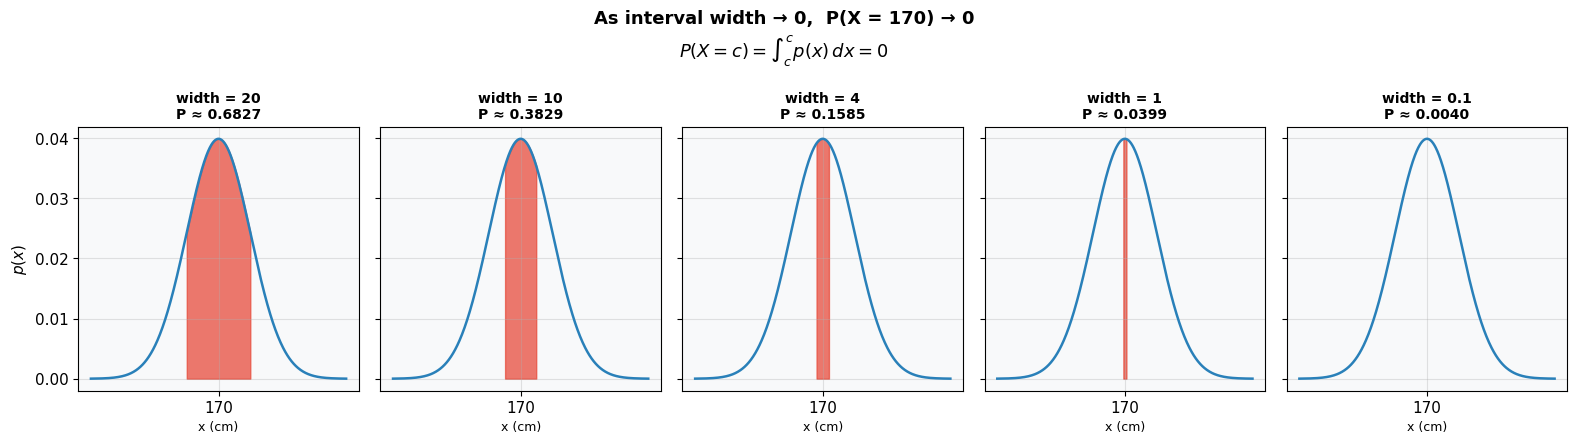

In [5]:
# --- P(X = c) = 0 illustration: shrinking interval width → 0 ---
mu, sigma = 170, 10
c = 170
interval_widths = [20, 10, 4, 1, 0.1]

fig, axes = plt.subplots(1, len(interval_widths), figsize=(16, 4.5), sharey=True)
x_range = np.linspace(130, 210, 600)
pdf_full = norm.pdf(x_range, mu, sigma)

for ax, w in zip(axes, interval_widths):
    a_i, b_i = c - w / 2, c + w / 2
    prob, _ = quad(norm.pdf, a_i, b_i, args=(mu, sigma))
    ax.plot(x_range, pdf_full, color='#2980b9', linewidth=1.8)
    mask = (x_range >= a_i) & (x_range <= b_i)
    ax.fill_between(x_range[mask], pdf_full[mask], color='#e74c3c', alpha=0.75)
    ax.set_title(f'width = {w}\nP ≈ {prob:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('x (cm)', fontsize=9)
    ax.set_xticks([c])
    ax.set_xticklabels([str(c)])

axes[0].set_ylabel('$p(x)$', fontsize=11)
plt.suptitle(
    f'As interval width → 0,  P(X = {c}) → 0\n'
    r'$P(X=c) = \int_c^c p(x)\,dx = 0$',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## PDF Properties Verification

For any valid PDF $p(x)$:

1. $p(x) \geq 0$ everywhere  
2. $\displaystyle\int_{-\infty}^{\infty} p(x)\, dx = 1$

In [7]:
# --- Verify PDF properties for common distributions ---
distributions = {
    'Normal(μ=0, σ=1)':   norm(0, 1),
    'Uniform(a=0, b=1)':  uniform(0, 1),
    'Exponential(λ=1)':   expon(scale=1),
    'Beta(α=2, β=5)':     beta_dist(2, 5),
}

print(f"{'Distribution':<25} {'Min p(x)':>12} {'∫p(x)dx':>12} {'Valid?':>8}")
print("-" * 62)
for name, dist in distributions.items():
    lo, hi = dist.ppf(0.00001), dist.ppf(0.99999)
    xs = np.linspace(lo, hi, 5000)
    ps = dist.pdf(xs)
    total, _ = quad(dist.pdf, lo, hi)
    valid = bool(np.all(ps >= -1e-10)) and np.isclose(total, 1.0, atol=1e-3)
    print(f"{name:<25} {ps.min():>12.6f} {total:>12.6f} {'✓' if valid else '✗':>8}")

Distribution                  Min p(x)      ∫p(x)dx   Valid?
--------------------------------------------------------------
Normal(μ=0, σ=1)              0.000045     0.999980        ✓
Uniform(a=0, b=1)             1.000000     0.999980        ✓
Exponential(λ=1)              0.000010     0.999980        ✓
Beta(α=2, β=5)                0.000698     0.999980        ✓


## PDF Gallery — Common Continuous Distributions

| Distribution | PDF $p(x)$ | Support | Parameters |
|---|---|---|---|
| **Uniform** | $\dfrac{1}{b-a}$ | $[a, b]$ | $a < b$ |
| **Normal** | $\dfrac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$ | $(-\infty, \infty)$ | $\mu,\, \sigma > 0$ |
| **Exponential** | $\lambda e^{-\lambda x}$ | $[0, \infty)$ | $\lambda > 0$ |
| **Beta** | $\dfrac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}$ | $[0, 1]$ | $\alpha, \beta > 0$ |

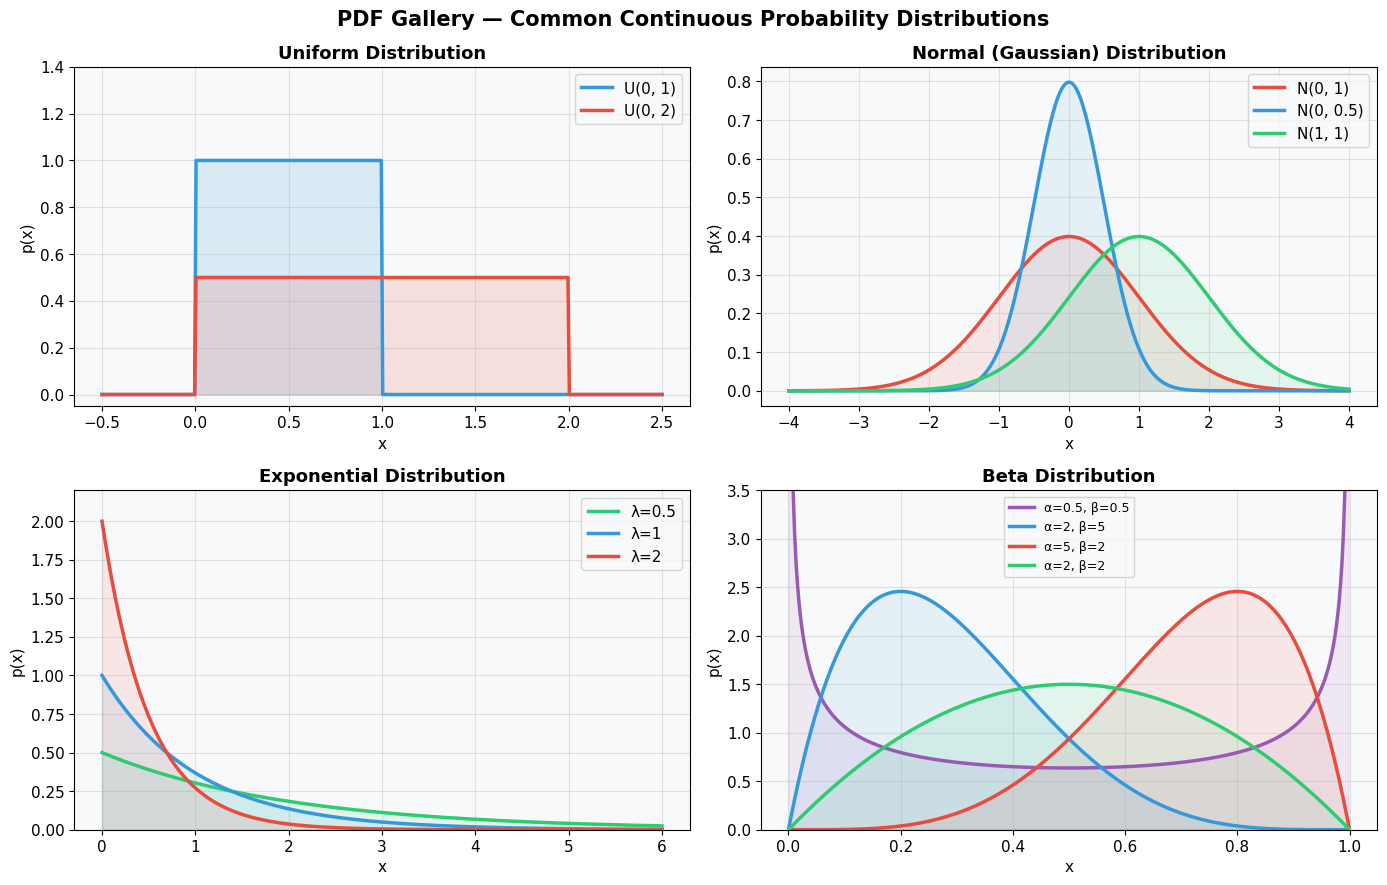

In [8]:
# --- PDF Gallery ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

# 1. Uniform
ax = axes[0]
x_u = np.linspace(-0.5, 2.5, 400)
for (a_u, b_u), col, lbl in [((0, 1), '#3498db', 'U(0, 1)'), ((0, 2), '#e74c3c', 'U(0, 2)')]:
    pdf_u = uniform.pdf(x_u, a_u, b_u - a_u)
    ax.plot(x_u, pdf_u, color=col, linewidth=2.5, label=lbl)
    ax.fill_between(x_u, pdf_u, alpha=0.15, color=col)
ax.set_title('Uniform Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('p(x)'); ax.legend(); ax.set_ylim(-0.05, 1.4)

# 2. Normal
ax = axes[1]
x_n = np.linspace(-4, 4, 400)
for (mu_n, sig_n), col, lbl in [((0, 1), '#e74c3c', 'N(0, 1)'),
                                  ((0, 0.5), '#3498db', 'N(0, 0.5)'),
                                  ((1, 1),   '#2ecc71', 'N(1, 1)')]:
    ax.plot(x_n, norm.pdf(x_n, mu_n, sig_n), color=col, linewidth=2.5, label=lbl)
    ax.fill_between(x_n, norm.pdf(x_n, mu_n, sig_n), alpha=0.10, color=col)
ax.set_title('Normal (Gaussian) Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('p(x)'); ax.legend()

# 3. Exponential
ax = axes[2]
x_e = np.linspace(0, 6, 400)
for lam, col, lbl in [(0.5, '#2ecc71', 'λ=0.5'), (1, '#3498db', 'λ=1'), (2, '#e74c3c', 'λ=2')]:
    pdf_e = expon.pdf(x_e, scale=1 / lam)
    ax.plot(x_e, pdf_e, color=col, linewidth=2.5, label=lbl)
    ax.fill_between(x_e, pdf_e, alpha=0.10, color=col)
ax.set_title('Exponential Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('p(x)'); ax.legend(); ax.set_ylim(0, 2.2)

# 4. Beta
ax = axes[3]
x_b = np.linspace(0.001, 0.999, 400)
for (a_b, b_b), col, lbl in [((0.5, 0.5), '#9b59b6', 'α=0.5, β=0.5'),
                               ((2, 5),     '#3498db', 'α=2, β=5'),
                               ((5, 2),     '#e74c3c', 'α=5, β=2'),
                               ((2, 2),     '#2ecc71', 'α=2, β=2')]:
    pdf_b = beta_dist.pdf(x_b, a_b, b_b)
    ax.plot(x_b, pdf_b, color=col, linewidth=2.5, label=lbl)
    ax.fill_between(x_b, pdf_b, alpha=0.10, color=col)
ax.set_title('Beta Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('p(x)'); ax.legend(fontsize=9); ax.set_ylim(0, 3.5)

plt.suptitle('PDF Gallery — Common Continuous Probability Distributions',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Computing Probabilities from the PDF

$$\Pr[a \leq x \leq b] = \int_a^b p(x)\, dx$$

### Example — Human Height: $X \sim \mathcal{N}(170,\, 10^2)$

What fraction of people fall within different height ranges?

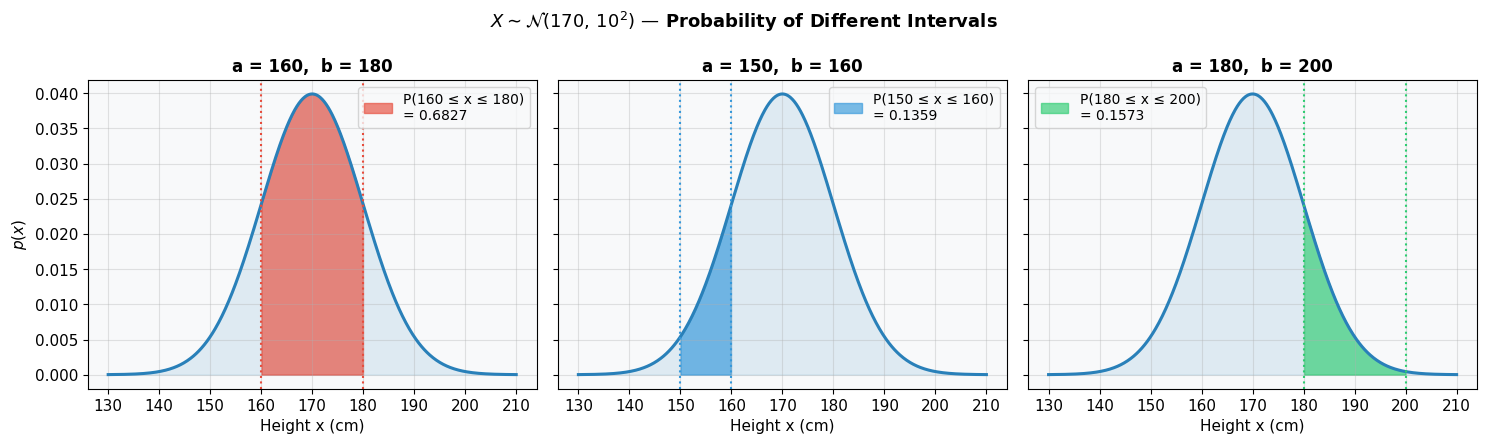

Computed probabilities:
  P(160 ≤ x ≤ 180)  =  0.682689
  P(150 ≤ x ≤ 160)  =  0.135905
  P(180 ≤ x ≤ 200)  =  0.157305


In [9]:
# --- Computing probabilities by integration ---
mu, sigma = 170, 10
queries = [
    (160, 180, '#e74c3c', 'P(160 ≤ x ≤ 180)'),
    (150, 160, '#3498db', 'P(150 ≤ x ≤ 160)'),
    (180, 200, '#2ecc71', 'P(180 ≤ x ≤ 200)'),
]

x = np.linspace(130, 210, 600)
pdf = norm.pdf(x, mu, sigma)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, (a, b, col, lbl) in zip(axes, queries):
    prob, _ = quad(norm.pdf, a, b, args=(mu, sigma))
    ax.plot(x, pdf, color='#2980b9', linewidth=2.2)
    ax.fill_between(x, pdf, alpha=0.12, color='#2980b9')
    mask = (x >= a) & (x <= b)
    ax.fill_between(x[mask], pdf[mask], color=col, alpha=0.65,
                    label=f'{lbl}\n= {prob:.4f}')
    ax.axvline(a, color=col, linestyle=':', linewidth=1.5)
    ax.axvline(b, color=col, linestyle=':', linewidth=1.5)
    ax.set_xlabel('Height x (cm)', fontsize=11)
    ax.set_title(f'a = {a},  b = {b}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)

axes[0].set_ylabel('$p(x)$', fontsize=11)
plt.suptitle(r'$X \sim \mathcal{N}(170,\, 10^2)$ — Probability of Different Intervals',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Computed probabilities:")
for a, b, _, lbl in queries:
    prob, _ = quad(norm.pdf, a, b, args=(mu, sigma))
    print(f"  {lbl}  =  {prob:.6f}")

## Cumulative Distribution Function (CDF)

The **CDF** is defined as:

$$F(x) = \Pr[X \leq x] = \int_{-\infty}^{x} p(t)\, dt$$

Key relationship:

$$p(x) = \frac{d}{dx} F(x) \qquad \text{(PDF is the derivative of the CDF)}$$

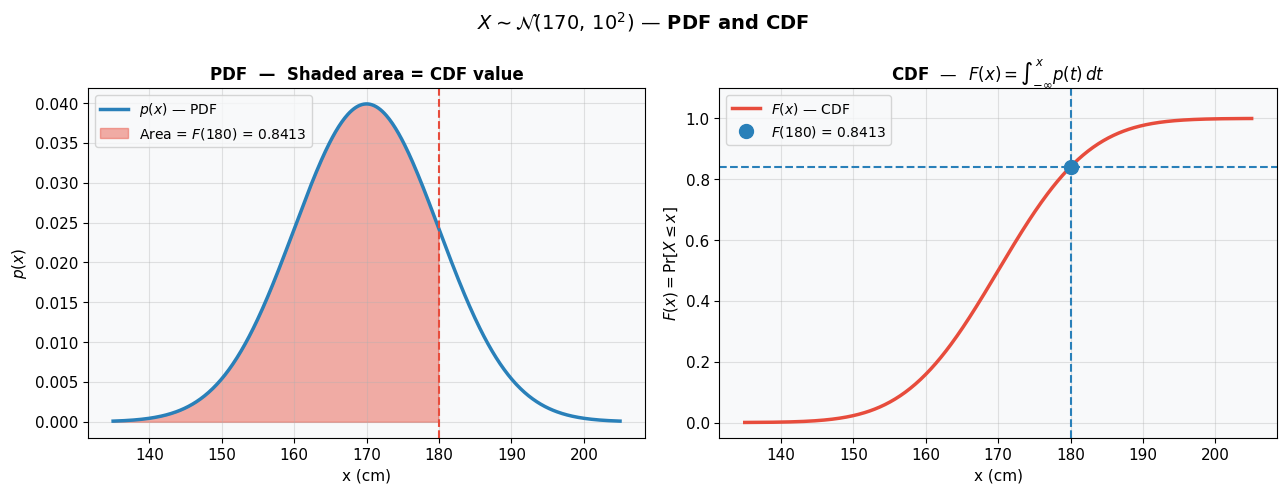

In [10]:
# --- PDF and CDF side by side ---
mu, sigma = 170, 10
x = np.linspace(135, 205, 500)
pdf_vals = norm.pdf(x, mu, sigma)
cdf_vals = norm.cdf(x, mu, sigma)
x_q = 180
prob_le_xq = norm.cdf(x_q, mu, sigma)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# PDF with area shaded up to x_q
ax1.plot(x, pdf_vals, color='#2980b9', linewidth=2.5, label='$p(x)$ — PDF')
mask = x <= x_q
ax1.fill_between(x[mask], pdf_vals[mask], color='#e74c3c', alpha=0.45,
                 label=f'Area = $F({x_q})$ = {prob_le_xq:.4f}')
ax1.axvline(x_q, color='#e74c3c', linestyle='--', linewidth=1.5)
ax1.set_xlabel('x (cm)'); ax1.set_ylabel('$p(x)$')
ax1.set_title('PDF  —  Shaded area = CDF value', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)

# CDF
ax2.plot(x, cdf_vals, color='#e74c3c', linewidth=2.5, label='$F(x)$ — CDF')
ax2.axvline(x_q, color='#2980b9', linestyle='--', linewidth=1.5)
ax2.axhline(prob_le_xq, color='#2980b9', linestyle='--', linewidth=1.5)
ax2.plot(x_q, prob_le_xq, 'o', color='#2980b9', markersize=10,
         label=f'$F({x_q})$ = {prob_le_xq:.4f}')
ax2.set_xlabel('x (cm)'); ax2.set_ylabel('$F(x) = \\Pr[X \\leq x]$')
ax2.set_title(r'CDF  —  $F(x) = \int_{-\infty}^x p(t)\,dt$', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10); ax2.set_ylim(-0.05, 1.1)

plt.suptitle(r'$X \sim \mathcal{N}(170,\, 10^2)$ — PDF and CDF',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## When to Use the CDF

| Use case | Formula | Example |
|---|---|---|
| **Left-tail probability** $P(X \leq b)$ | $F(b)$ | What fraction of people are ≤ 180 cm? |
| **Range probability** $P(a \leq X \leq b)$ | $F(b) - F(a)$ | What fraction are between 160 and 180 cm? |
| **Right-tail probability** $P(X > b)$ | $1 - F(b)$ | What fraction are taller than 190 cm? |
| **Quantile / percentile** | $F^{-1}(p)$ | What height is the 90th percentile? |
| **Median** | $F^{-1}(0.5)$ | Height that splits the population 50/50 |

> **Rule of thumb**: Use the **PDF** when you care about the *shape* or *relative likelihood*; use the **CDF** when you need an *actual probability* (area under the curve).

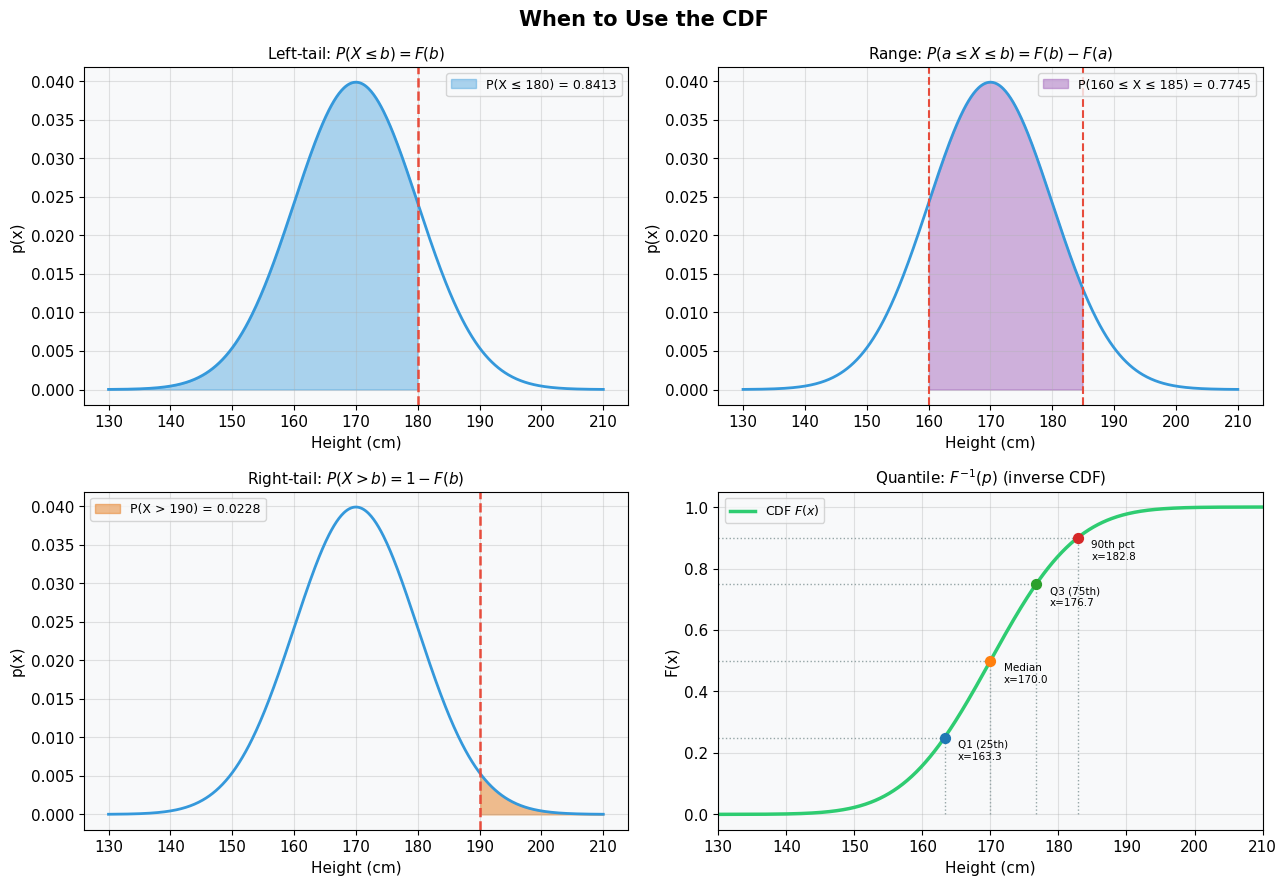

────────────────────────────────────────────────────
Use case                          Value
────────────────────────────────────────────────────
P(X ≤ 180)                       0.8413
P(160 ≤ X ≤ 185)                 0.7745
P(X > 190)                       0.0228
Median (50th pct)              170.0000 cm
90th percentile                182.8155 cm
────────────────────────────────────────────────────


In [14]:
# --- When to use the CDF: 4-panel illustration ---
mu, sigma = 170, 10
x_full = np.linspace(130, 210, 600)
pdf_full = norm.pdf(x_full, mu, sigma)
cdf_full = norm.cdf(x_full, mu, sigma)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('When to Use the CDF', fontsize=15, fontweight='bold')

colors = {'shade': '#3498db', 'cdf': '#2ecc71', 'line': '#e74c3c'}

# ── Panel 1: Left-tail P(X ≤ 180) ──────────────────────────────────────────
ax = axes[0, 0]
b = 180
prob = norm.cdf(b, mu, sigma)
ax.plot(x_full, pdf_full, color=colors['shade'], lw=2)
ax.fill_between(x_full, pdf_full, where=(x_full <= b),
                color=colors['shade'], alpha=0.4, label=f'P(X ≤ {b}) = {prob:.4f}')
ax.axvline(b, color=colors['line'], lw=1.8, ls='--')
ax.set_title(r'Left-tail: $P(X \leq b) = F(b)$', fontsize=11)
ax.set_xlabel('Height (cm)'); ax.set_ylabel('p(x)')
ax.legend(fontsize=9)

# ── Panel 2: Range P(160 ≤ X ≤ 185) ───────────────────────────────────────
ax = axes[0, 1]
a, b = 160, 185
prob = norm.cdf(b, mu, sigma) - norm.cdf(a, mu, sigma)
ax.plot(x_full, pdf_full, color=colors['shade'], lw=2)
ax.fill_between(x_full, pdf_full, where=((x_full >= a) & (x_full <= b)),
                color='#9b59b6', alpha=0.45, label=f'P({a} ≤ X ≤ {b}) = {prob:.4f}')
ax.axvline(a, color=colors['line'], lw=1.5, ls='--')
ax.axvline(b, color=colors['line'], lw=1.5, ls='--')
ax.set_title(r'Range: $P(a \leq X \leq b) = F(b) - F(a)$', fontsize=11)
ax.set_xlabel('Height (cm)'); ax.set_ylabel('p(x)')
ax.legend(fontsize=9)

# ── Panel 3: Right-tail P(X > 190) ─────────────────────────────────────────
ax = axes[1, 0]
b = 190
prob = 1 - norm.cdf(b, mu, sigma)
ax.plot(x_full, pdf_full, color=colors['shade'], lw=2)
ax.fill_between(x_full, pdf_full, where=(x_full >= b),
                color='#e67e22', alpha=0.5, label=f'P(X > {b}) = {prob:.4f}')
ax.axvline(b, color=colors['line'], lw=1.8, ls='--')
ax.set_title(r'Right-tail: $P(X > b) = 1 - F(b)$', fontsize=11)
ax.set_xlabel('Height (cm)'); ax.set_ylabel('p(x)')
ax.legend(fontsize=9)

# ── Panel 4: Quantiles via inverse CDF ─────────────────────────────────────
ax = axes[1, 1]
ax.plot(x_full, cdf_full, color=colors['cdf'], lw=2.5, label='CDF $F(x)$')
for p, lbl in [(0.25, 'Q1 (25th)'), (0.50, 'Median'), (0.75, 'Q3 (75th)'), (0.90, '90th pct')]:
    q = norm.ppf(p, mu, sigma)
    ax.plot([130, q], [p, p], color='#95a5a6', lw=1, ls=':')
    ax.plot([q, q], [0, p],   color='#95a5a6', lw=1, ls=':')
    ax.scatter([q], [p], zorder=5, s=50)
    ax.annotate(f'{lbl}\nx={q:.1f}', xy=(q, p), xytext=(q + 2, p - 0.07),
                fontsize=7.5, ha='left')
ax.set_title(r'Quantile: $F^{-1}(p)$ (inverse CDF)', fontsize=11)
ax.set_xlabel('Height (cm)'); ax.set_ylabel('F(x)')
ax.set_xlim(130, 210); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print("─" * 52)
print(f"{'Use case':<28} {'Value':>10}")
print("─" * 52)
print(f"P(X ≤ 180)                   {norm.cdf(180, mu, sigma):>10.4f}")
print(f"P(160 ≤ X ≤ 185)             {norm.cdf(185, mu, sigma) - norm.cdf(160, mu, sigma):>10.4f}")
print(f"P(X > 190)                   {1 - norm.cdf(190, mu, sigma):>10.4f}")
print(f"Median (50th pct)            {norm.ppf(0.50, mu, sigma):>10.4f} cm")
print(f"90th percentile              {norm.ppf(0.90, mu, sigma):>10.4f} cm")
print("─" * 52)

## Expected Value and Variance from the PDF

For a continuous random variable, summary statistics are computed via integration:

$$\mathbb{E}[X] = \int_{-\infty}^{\infty} x\, p(x)\, dx$$

$$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \int_{-\infty}^{\infty} x^2\, p(x)\, dx - \left(\mathbb{E}[X]\right)^2$$

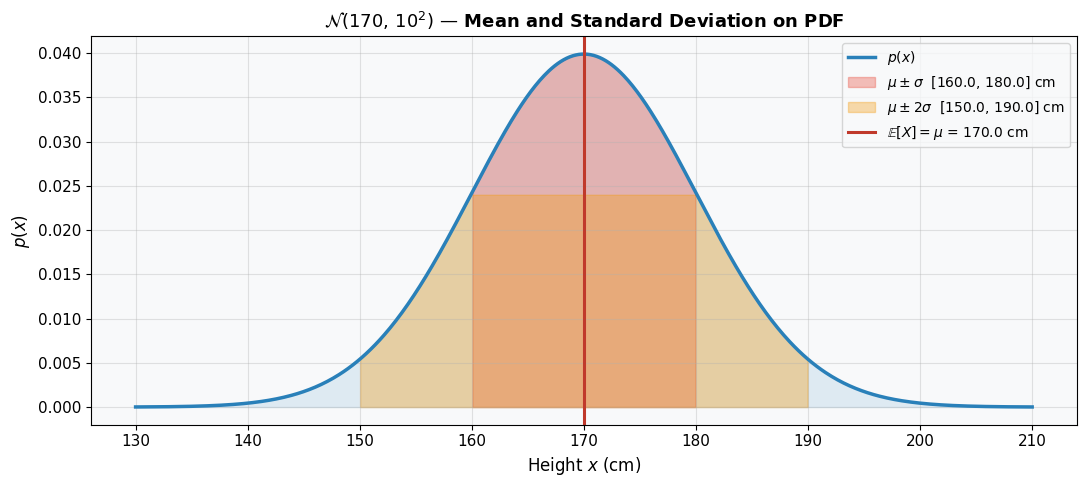

E[X]   = ∫ x·p(x) dx        = 170.0000
E[X²]  = ∫ x²·p(x) dx       = 29000.0000
Var(X) = E[X²] - (E[X])²    = 100.0000
Std(X) = √Var(X)             = 10.0000


In [12]:
# --- E[X] and Var(X) visualized on the PDF ---
mu, sigma = 170, 10
x = np.linspace(130, 210, 600)
pdf = norm.pdf(x, mu, sigma)

# Use wide finite bounds (±8σ) to avoid numerical cancellation with infinite limits
lo, hi = mu - 8*sigma, mu + 8*sigma
E_X,  _ = quad(lambda t: t * norm.pdf(t, mu, sigma), lo, hi)
E_X2, _ = quad(lambda t: t**2 * norm.pdf(t, mu, sigma), lo, hi)
Var_X   = E_X2 - E_X**2
std_X   = np.sqrt(Var_X)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, pdf, color='#2980b9', linewidth=2.5, label='$p(x)$')
ax.fill_between(x, pdf, alpha=0.12, color='#2980b9')

mask_1s = (x >= E_X - std_X) & (x <= E_X + std_X)
ax.fill_between(x[mask_1s], pdf[mask_1s], color='#e74c3c', alpha=0.35,
                label=f'$\\mu \\pm \\sigma$  [{E_X - std_X:.1f}, {E_X + std_X:.1f}] cm')

mask_2s = ((x >= E_X - 2*std_X) & (x < E_X - std_X)) | \
          ((x > E_X + std_X) & (x <= E_X + 2*std_X))
ax.fill_between(x[mask_2s], pdf[mask_2s], color='#f39c12', alpha=0.35,
                label=f'$\\mu \\pm 2\\sigma$  [{E_X - 2*std_X:.1f}, {E_X + 2*std_X:.1f}] cm')

ax.axvline(E_X, color='#c0392b', linewidth=2.2, linestyle='-',
           label=f'$\\mathbb{{E}}[X] = \\mu$ = {E_X:.1f} cm')

ax.set_xlabel('Height $x$ (cm)', fontsize=12)
ax.set_ylabel('$p(x)$', fontsize=12)
ax.set_title(r'$\mathcal{N}(170,\, 10^2)$ — Mean and Standard Deviation on PDF',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"E[X]   = ∫ x·p(x) dx        = {E_X:.4f}")
print(f"E[X²]  = ∫ x²·p(x) dx       = {E_X2:.4f}")
print(f"Var(X) = E[X²] - (E[X])²    = {Var_X:.4f}")
print(f"Std(X) = √Var(X)             = {std_X:.4f}")

## PMF vs PDF — Side-by-Side Comparison

| | **PMF** — Discrete | **PDF** — Continuous |
|---|---|---|
| Variable type | Countable values | Uncountable (real-valued) |
| Notation | $P(X = k)$ | $p(x)$ |
| Individual point | $P(X = k) \geq 0$ possible | $P(X = c) = 0$ always |
| Probability of range | $\displaystyle\sum_{k=a}^{b} P(X=k)$ | $\displaystyle\int_a^b p(x)\,dx$ |
| Normalisation | $\displaystyle\sum_k P(X=k) = 1$ | $\displaystyle\int_{-\infty}^{\infty} p(x)\,dx = 1$ |
| Example | Die roll, coin flip | Height, weight, temperature |

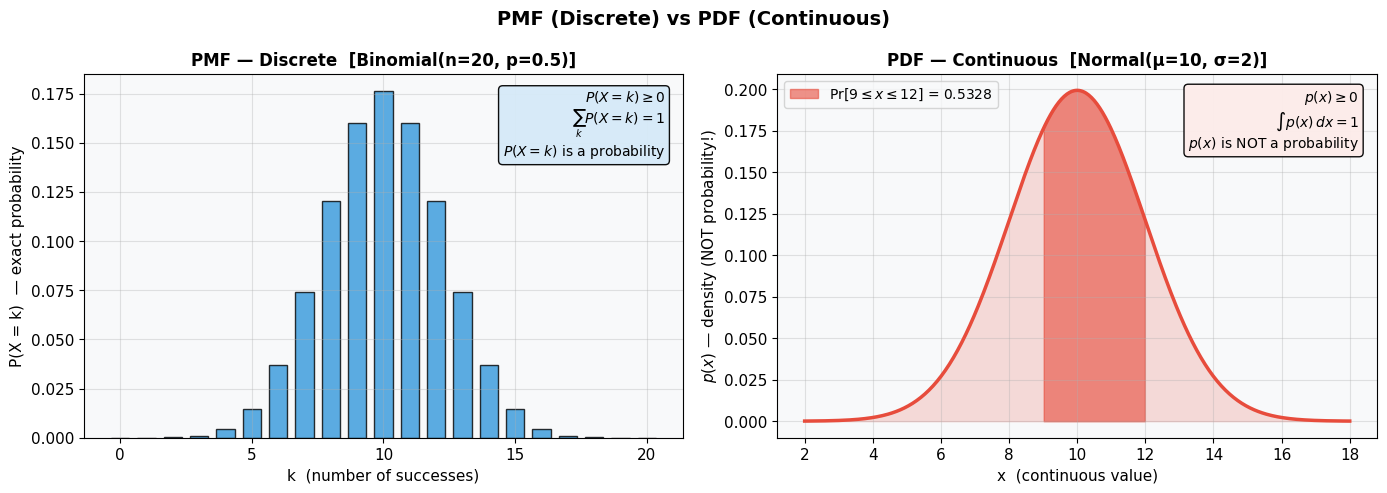

In [13]:
# --- PMF vs PDF side-by-side ---
from scipy.stats import binom

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PMF — Binomial
ax1 = axes[0]
n, p_binom = 20, 0.5
k = np.arange(0, n + 1)
pmf = binom.pmf(k, n, p_binom)
ax1.bar(k, pmf, color='#3498db', edgecolor='black', alpha=0.8, width=0.7)
ax1.set_title('PMF — Discrete  [Binomial(n=20, p=0.5)]', fontsize=12, fontweight='bold')
ax1.set_xlabel('k  (number of successes)')
ax1.set_ylabel('P(X = k)  — exact probability')
ax1.text(0.97, 0.96,
         '$P(X=k) \\geq 0$\n$\\sum_k P(X=k) = 1$\n$P(X=k)$ is a probability',
         transform=ax1.transAxes, ha='right', va='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#d6eaf8', alpha=0.95))

# PDF — Normal
ax2 = axes[1]
mu_n, sig_n = 10, 2
x_n = np.linspace(2, 18, 400)
pdf_n = norm.pdf(x_n, mu_n, sig_n)
ax2.plot(x_n, pdf_n, color='#e74c3c', linewidth=2.5)
ax2.fill_between(x_n, pdf_n, alpha=0.18, color='#e74c3c')
a_n, b_n = 9, 12
mask_n = (x_n >= a_n) & (x_n <= b_n)
prob_n, _ = quad(norm.pdf, a_n, b_n, args=(mu_n, sig_n))
ax2.fill_between(x_n[mask_n], pdf_n[mask_n], color='#e74c3c', alpha=0.6,
                 label=f'$\\Pr[{a_n} \\leq x \\leq {b_n}]$ = {prob_n:.4f}')
ax2.set_title('PDF — Continuous  [Normal(μ=10, σ=2)]', fontsize=12, fontweight='bold')
ax2.set_xlabel('x  (continuous value)')
ax2.set_ylabel('$p(x)$ — density (NOT probability!)')
ax2.legend(fontsize=10)
ax2.text(0.97, 0.96,
         '$p(x) \\geq 0$\n$\\int p(x)\\,dx = 1$\n$p(x)$ is NOT a probability',
         transform=ax2.transAxes, ha='right', va='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#fdecea', alpha=0.95))

plt.suptitle('PMF (Discrete) vs PDF (Continuous)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Concept | Key Point |
|---|---|
| **Continuous RV** | Takes any real value; $x \in \mathbb{R}$ |
| **PDF $p(x)$** | Describes probability *density*, not probability at a point |
| **Probability** | Always an *area*: $\Pr[a \leq x \leq b] = \int_a^b p(x)\,dx$ |
| **Point probability** | $P(X = c) = 0$ for any single value $c$ |
| **Valid PDF** | $p(x) \geq 0$ and $\int_{-\infty}^{\infty} p(x)\,dx = 1$ |
| **CDF** | $F(x) = \int_{-\infty}^x p(t)\,dt$; derivative of CDF = PDF |
| **$\mathbb{E}[X]$** | $\int_{-\infty}^{\infty} x\,p(x)\,dx$ |
| **$\text{Var}(X)$** | $\int x^2 p(x)\,dx - (\mathbb{E}[X])^2$ |